In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[2]
print(project_root)
sys.path.append(str(project_root))

/Users/kangyopchi/Firenodes/Projects/FIREgen


In [2]:
# pip install -qU langchain-core langchain-upstage
import os

from dotenv import load_dotenv
from langchain_upstage import UpstageEmbeddings

load_dotenv(project_root / ".env")


embeddings = UpstageEmbeddings(
    api_key=os.getenv("UPSTAGE_API_KEY"), model="embedding-query"
)

doc_result = embeddings.embed_query(["Sam is a teacher.", "This is another document"])
print(doc_result)


[0.01255035400390625, -0.001827239990234375, -0.01071929931640625, 0.0167083740234375, -0.00010627508163452148, 0.004146575927734375, -0.00739288330078125, -0.01331329345703125, -0.0282135009765625, 0.024810791015625, -0.0008106231689453125, 0.0069580078125, 0.01396942138671875, 0.005451202392578125, 0.01515960693359375, 0.00391387939453125, -0.001003265380859375, 0.01412200927734375, -0.03314208984375, -0.0014057159423828125, -0.0205078125, -0.01007080078125, -0.01068115234375, -0.0162811279296875, -0.036865234375, 0.004116058349609375, 0.004100799560546875, -0.00788116455078125, 0.0037441253662109375, 0.0264434814453125, 0.0037555694580078125, 0.007904052734375, -0.01349639892578125, -0.00069427490234375, -0.006134033203125, 0.005828857421875, -0.0237884521484375, 0.02099609375, 0.0157012939453125, 0.01514434814453125, -0.012969970703125, -0.007793426513671875, -0.005062103271484375, -0.00787353515625, -0.0059814453125, -0.003559112548828125, 0.010650634765625, 0.0031299591064453125,

In [3]:
print(len(doc_result[0]))

TypeError: object of type 'float' has no len()

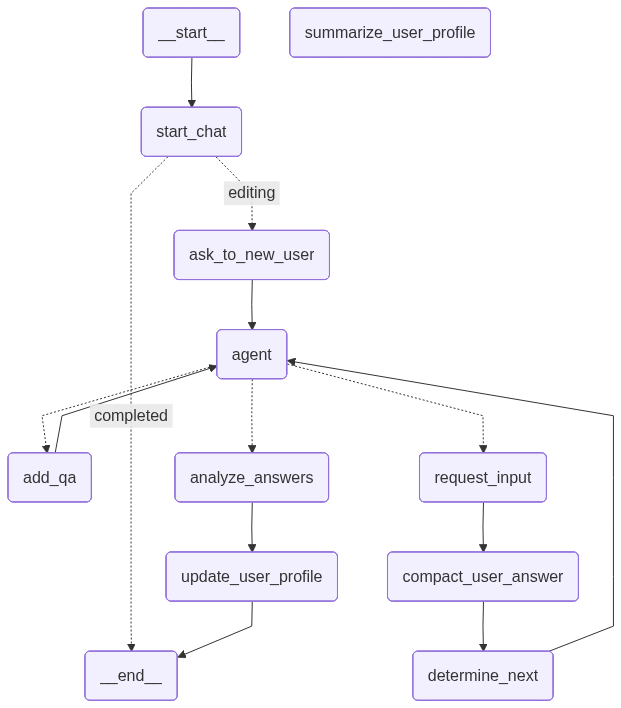

In [ ]:
from IPython.display import Image, display
from langchain_core.messages import AnyMessage
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph

from my_app.chatbot.chat_core.nodes import (
    analyze_user_answers,
    call_llm,
    compact_user_answer,
    create_followup_qa,
    determine_next_node,
    generate_greeting_message,
    present_predefined_questions,
    process_human_input_tool,
    summarize_user_profile,
    update_user_profile,
)
from my_app.chatbot.chat_core.state import InputState, OutputState, OverallState


def determine_initial_node(state: OverallState) -> str | None:
    profile_status = state.user_meta_data.get("profile_status", None)

    if profile_status is None:
        raise ValueError("Profile status is not found in the user meta data.")

    if profile_status == "completed":
        return END

    return profile_status


def route_after_agent(state: OverallState):
    messages: list[AnyMessage] = state.messages
    last_message: AnyMessage = messages[-1]

    try:
        tool_calls = getattr(last_message, "tool_calls", None)

        if not tool_calls:
            return END

        if tool_calls[0]["name"] == "RequestHumanInput":
            return "request_input"
        elif tool_calls[0]["name"] == "GenerateFollowUp":
            return "add_qa"
        elif tool_calls[0]["name"] == "AnalyzeProfile":
            return "analyze_answers"
        return END

    except AttributeError:
        return END


def route_after_update(state: OverallState):
    profile_status = state.user_meta_data.get("profile_status", None)

    try:
        if profile_status == "completed":
            return "summarize_user_profile"
        elif profile_status == "onboarding" or profile_status == "editing":
            return "ask_to_new_user"

    except AttributeError:
        return END


workflow = StateGraph(OverallState, input_schema=InputState, output_schema=OutputState)
workflow.add_node("start_chat", generate_greeting_message)
workflow.add_node("ask_to_new_user", present_predefined_questions)
workflow.add_node("agent", call_llm)
workflow.add_node("add_qa", create_followup_qa)
workflow.add_node("compact_user_answer", compact_user_answer)
workflow.add_node("determine_next", determine_next_node)
workflow.add_node("request_input", process_human_input_tool)
workflow.add_node("analyze_answers", analyze_user_answers)
workflow.add_node("update_user_profile", update_user_profile)
workflow.add_node("summarize_user_profile", summarize_user_profile)

memory = InMemorySaver()

workflow.add_edge(START, "start_chat")
workflow.add_conditional_edges(
    "start_chat",
    determine_initial_node,
    {
        "onboarding": "ask_to_new_user",
        "editing": "ask_to_new_user",
        "completed": END,  # TODO: 기존 사용자 subgraph 추가 필요
    },
)
workflow.add_edge("ask_to_new_user", "agent")
workflow.add_conditional_edges(
    "agent",
    route_after_agent,
    path_map=["request_input", "add_qa", "analyze_answers"],
)

workflow.add_edge("request_input", "compact_user_answer")
workflow.add_edge("compact_user_answer", "determine_next")
workflow.add_edge("determine_next", "agent")
workflow.add_edge("add_qa", "agent")
workflow.add_edge("analyze_answers", "update_user_profile")
workflow.add_edge("update_user_profile", END)

graph = workflow.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))


In [ ]:
from langchain_core.runnables import RunnableConfig

from my_app.chatbot.chat_core.state import InputState
from my_app.chatbot.services import MockProfileService

user_data = InputState(
    target_profile_category=[
        "investment_goal",
        "investment_emotions",
        "interests_categories",
        "investment_level",
        "knowledge_level",
        "risk_tolerance",
    ],
    user_meta_data={
        "name": "강요셉",
        "profile_status": "onboarding",
        "investment_goal": [],
        "investment_emotions": [],
        "interests_categories": [],
        "investment_level": [],
        "knowledge_level": [],
        "risk_tolerance": 0,
    },
)

config: RunnableConfig | None = {
    "configurable": {"thread_id": "1", "profile_service": MockProfileService()}
}

message_data = []
events = []

for event in graph.stream(user_data, config, stream_mode="values"):
    events.append(event)
    if "messages" in event:
        data = event["messages"]
        message_data.append(data)
        if isinstance(data, list):
            for message in data:
                message.pretty_print()
        else:
            data.pretty_print()
